In [1]:
%cd ../..

/scratch/big/home/daawic/BSc-Thesis


In [2]:
import os
import torch
import matplotlib.pyplot as plt
import scienceplots
from torchvision.transforms import transforms
from project.models import EDMCallum
from project.util.device import get_available_acc
from project.util.plotting import plot_sample
from project.util.data import ReplayMemoryData
from project.util.metrics import PSNR, MSE

In [3]:
plt.style.use(['science','no-latex', 'ieee'])

In [4]:
PATH = os.path.join("..", "checkpoints", "diff", "Breakout.pt")
DATA = os.path.join("..", "checkpoints", "memory", "Breakout.pt")
IMAGES = 100

In [5]:
device = "cuda:1"

In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Pad(2),
    transforms.Normalize(0.5, 0.5),
])

In [7]:
data = ReplayMemoryData(
    memory=DATA,
    transform=transform,
    cap=500_000,
    train=False,
)

In [8]:
model = EDMCallum.from_checkpoint(PATH, device, U=20).to(device)

In [ ]:
x = torch.zeros((IMAGES, 4, 88, 88), device=device)

for i, img in enumerate(torch.randperm(500_000)[:IMAGES]):
    x[i] = data[img].to(device)

mask = torch.ones_like(x, device=device)
mask[:, 2:] = 0

x_masked = x * mask
x_inpainted = model.inpaint(x, mask)

 56%|█████▋    | 18/32 [08:01<06:14, 26.77s/it]

In [ ]:
mses = torch.zeros(IMAGES)

for i in range(IMAGES):
    mses[i] = MSE(x[i, 2:], x_inpainted[i, 2:])

mse = mses.mean()

In [ ]:
print(f"MSE: {mses.mean()} (SE: {mses.std() / IMAGES ** 0.5})")

MSE: 0.0012415340170264244 (SE: 0.00010840259346878156)


(array([26., 10.,  3.,  1., 14., 16.,  8.,  4.,  7.,  4.,  1.,  2.,  0.,
         1.,  1.,  1.,  0.,  0.,  0.,  1.]),
 array([1.88725960e-06, 2.73085258e-04, 5.44283248e-04, 8.15481239e-04,
        1.08667917e-03, 1.35787716e-03, 1.62907515e-03, 1.90027314e-03,
        2.17147125e-03, 2.44266912e-03, 2.71386723e-03, 2.98506534e-03,
        3.25626321e-03, 3.52746109e-03, 3.79865919e-03, 4.06985730e-03,
        4.34105517e-03, 4.61225305e-03, 4.88345092e-03, 5.15464926e-03,
        5.42584714e-03]),
 <BarContainer object of 20 artists>)

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


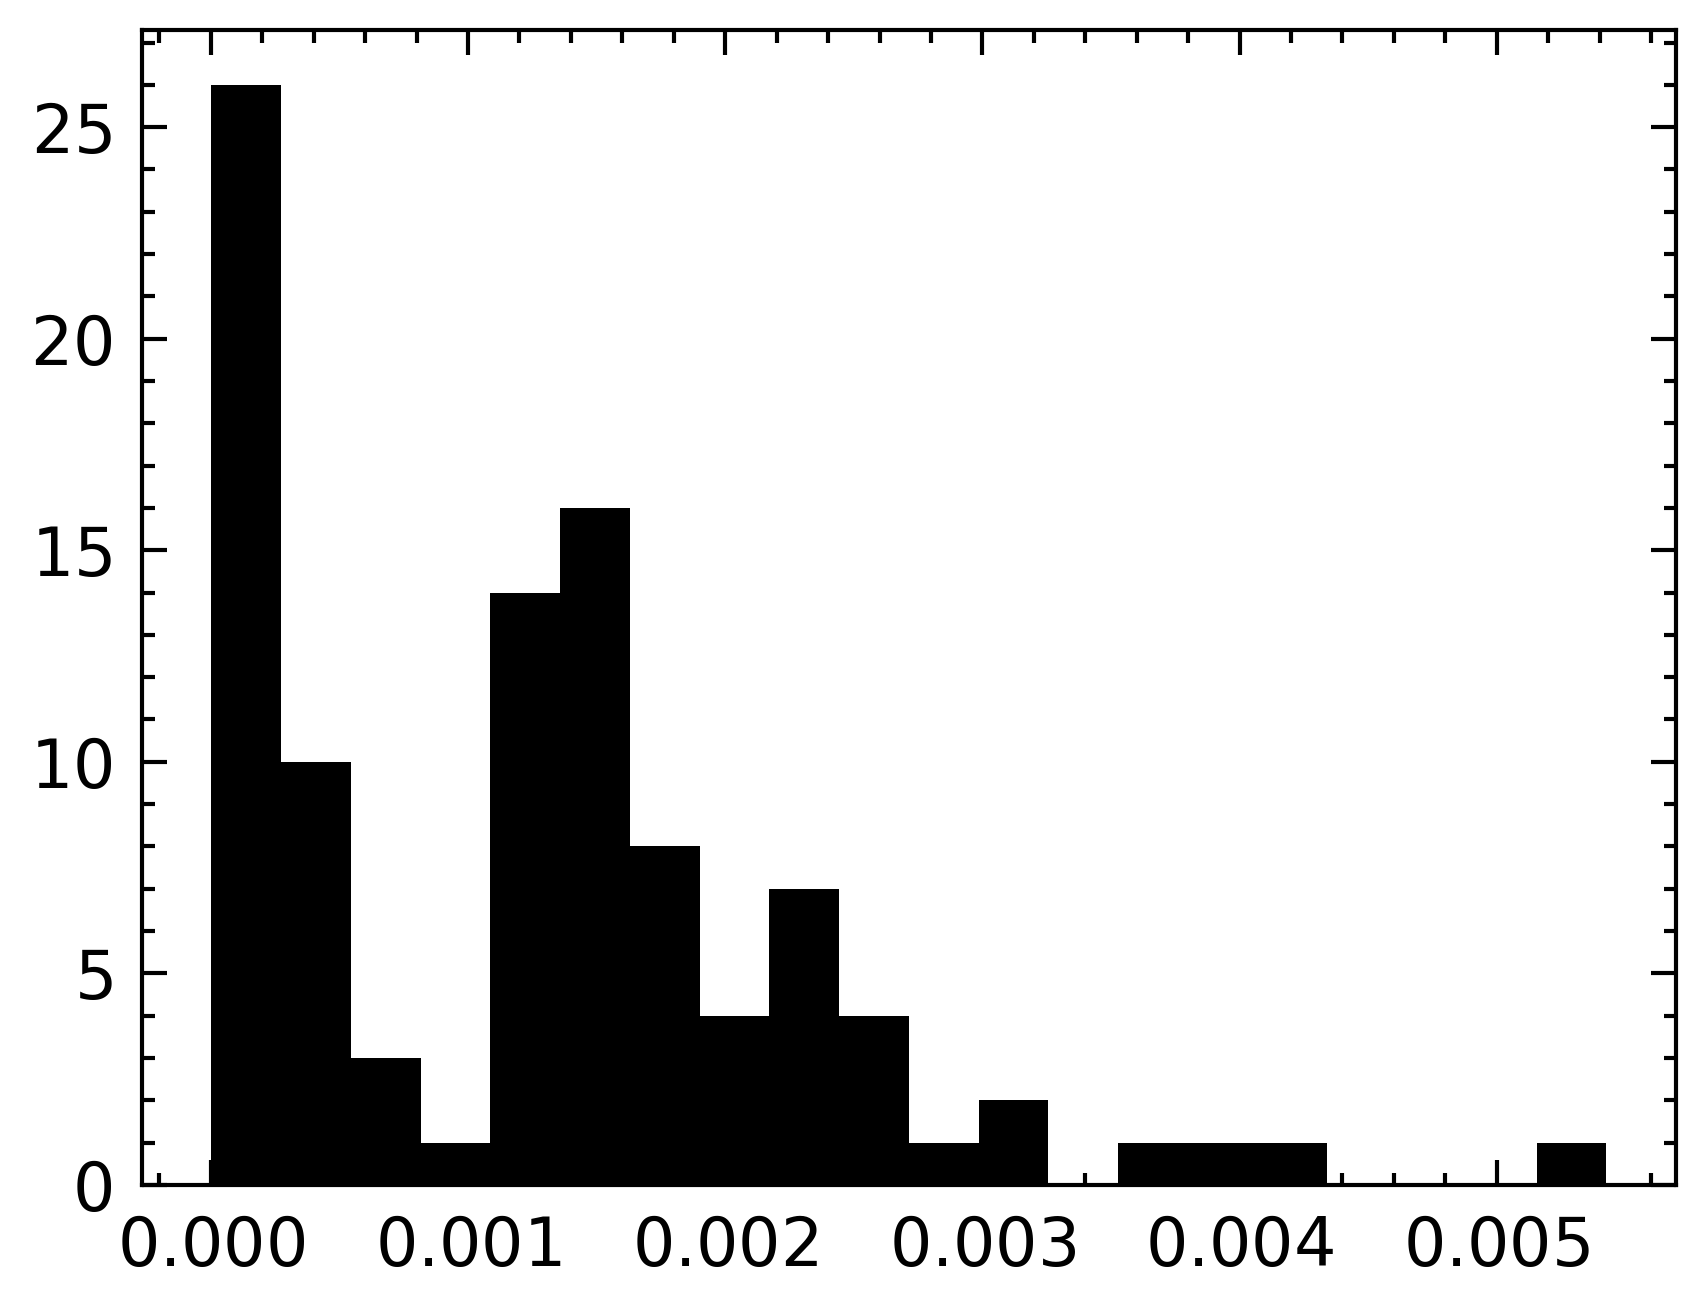

In [ ]:
plt.hist(mses, bins=20)

In [ ]:
randomized = torch.zeros((10000,))

for i in range(10000):
    perm = torch.randperm(100)
    randomized[i] = MSE(x[perm, 2:], x_inpainted[:, 2:])

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'se

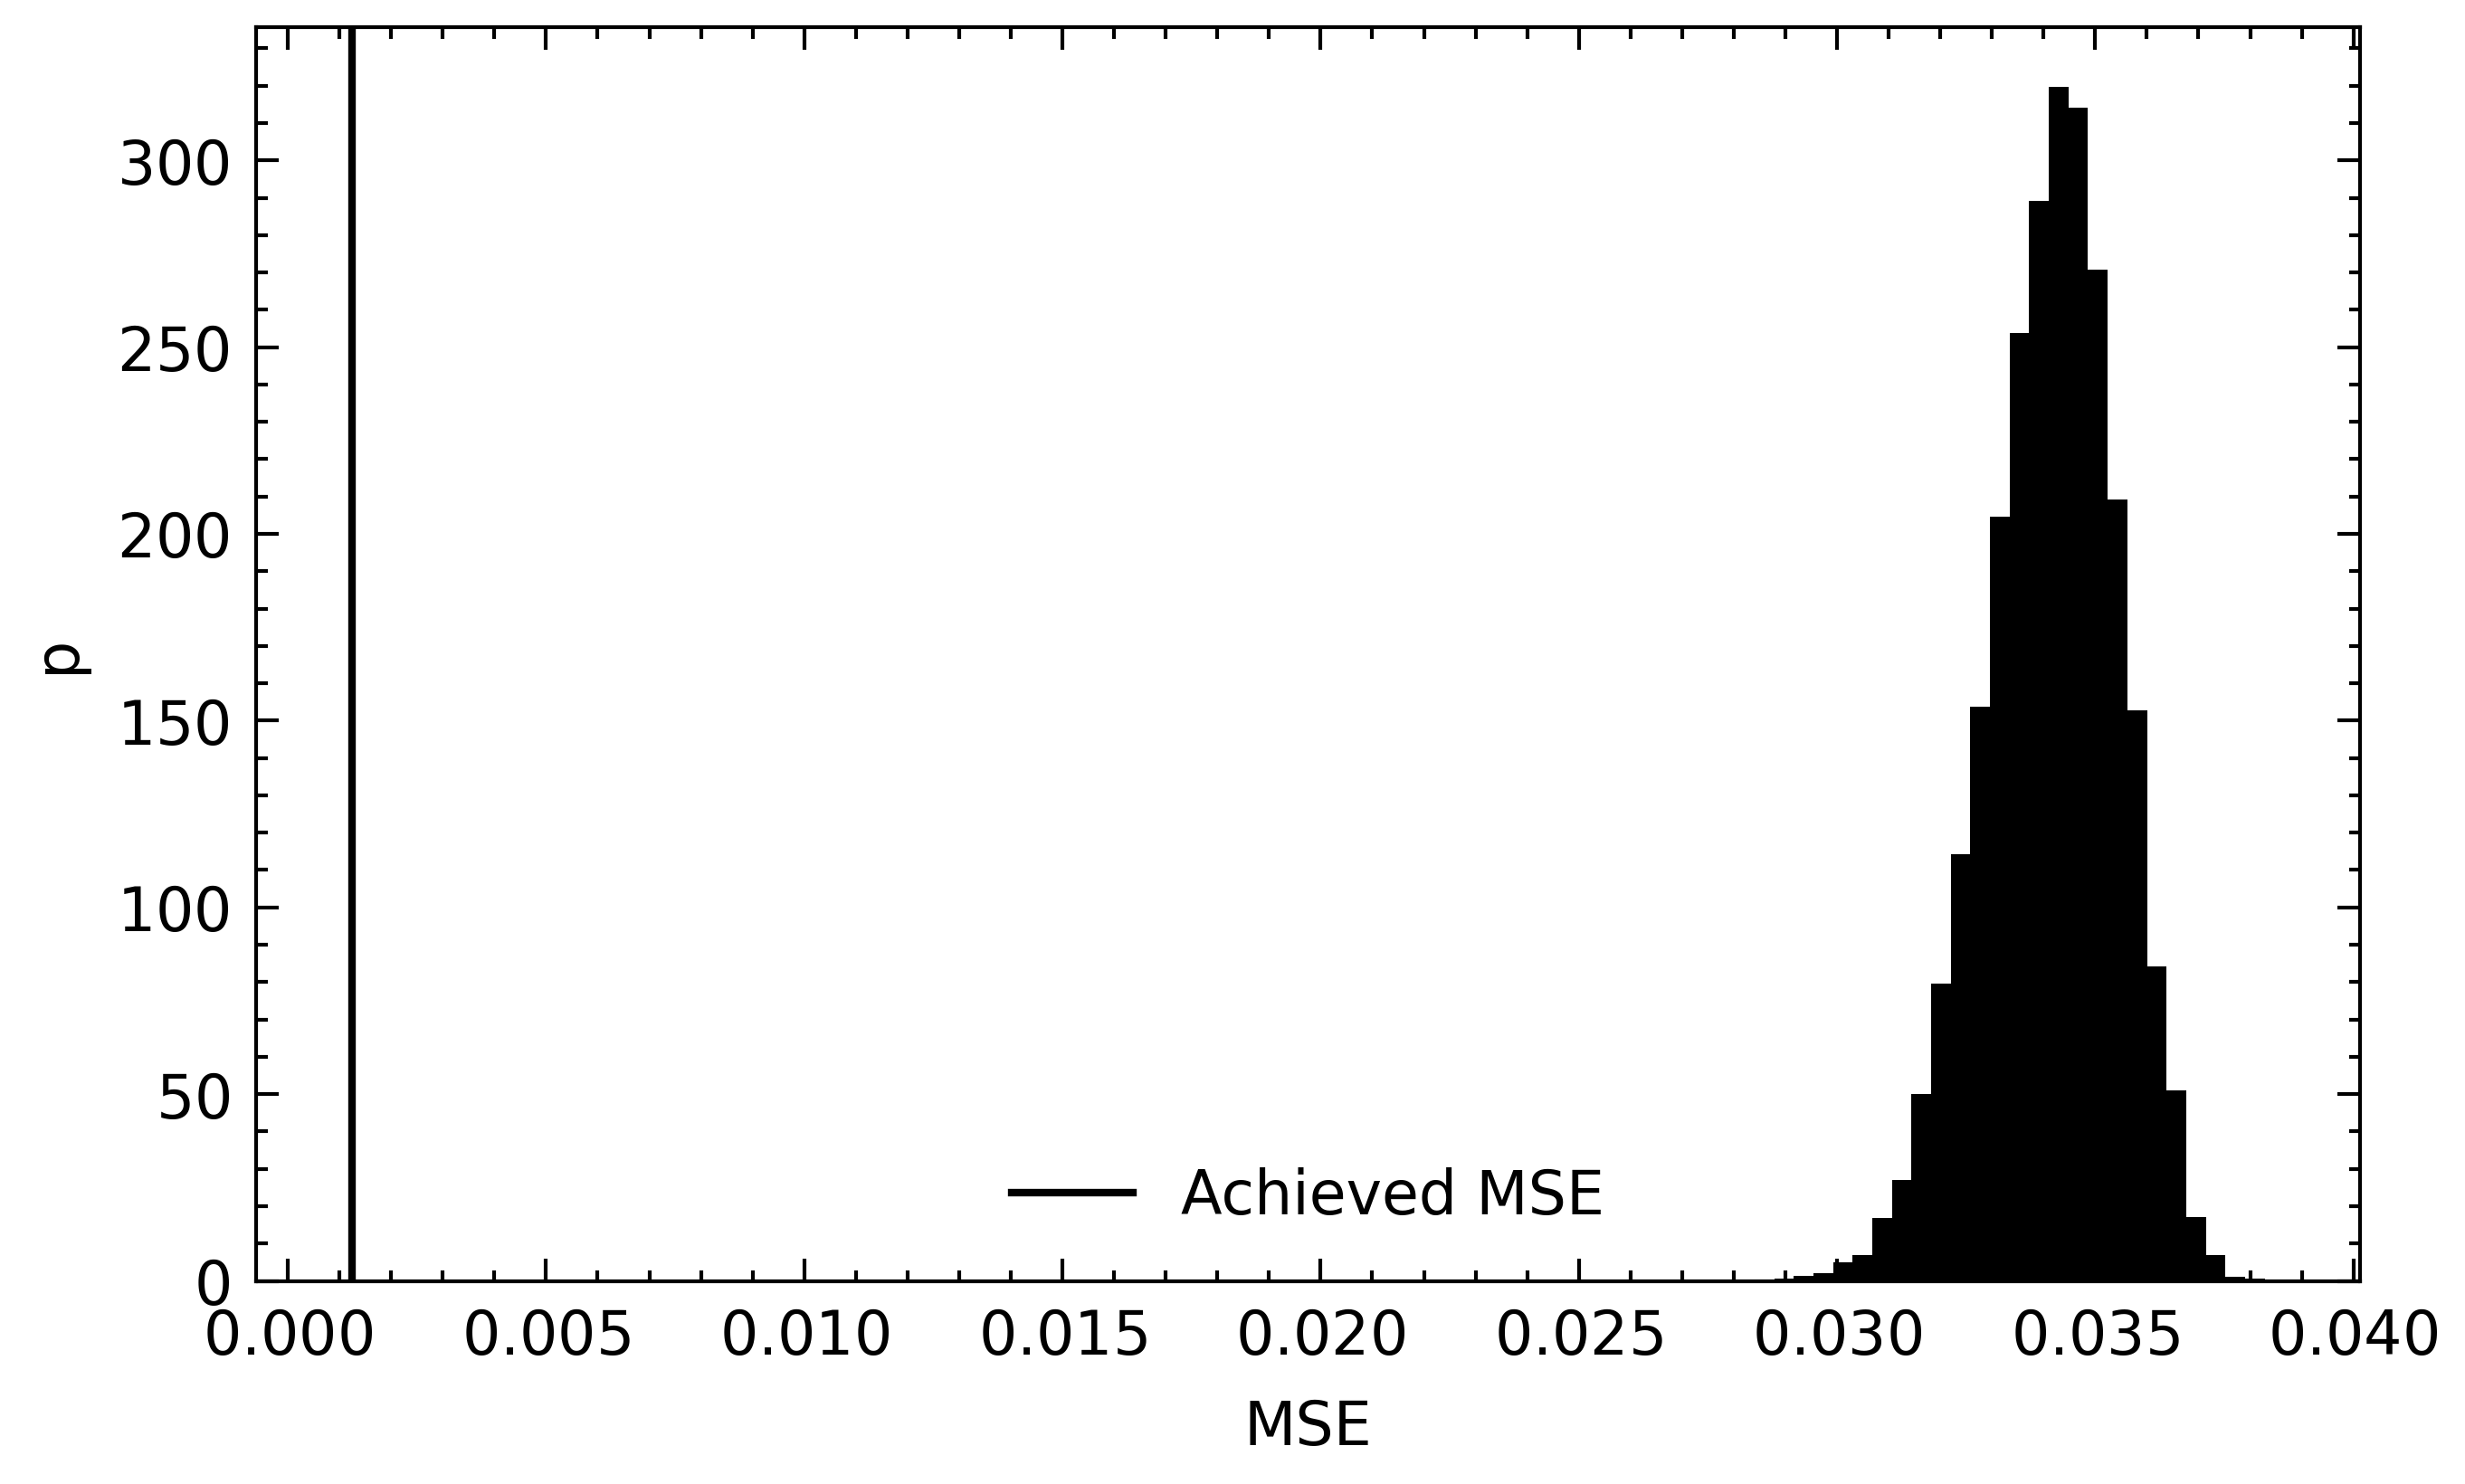

In [ ]:
plt.figure(figsize=(5, 3))

plt.hist(randomized, bins=25, density=True)
plt.axvline(mse, label="Achieved MSE by the diffusion model")
plt.ylabel("p")
plt.xlabel("MSE")

plt.legend()
plt.grid()

plt.savefig("../results/inpainting/frames/mse.svg")
plt.show()